In [8]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

#Define the system and the initial state
psi = (qt.basis(2,0) + qt.basis(2,1)).unit()  #|+> state
rho_0 = qt.ket2dm(psi)   #Density matrix of the initial state 

#Define the noise channel
gamma = 0.1    #Dephasing rate 
#Dephasing is physically represented by the Pauli Z matrix
#We scale it by the square root of the rate because of how the master equation is formulated
c_ops = [np.sqrt(gamma) * qt.sigmaz()]

#Define the time steps for the evolution
t_steps = np.linspace(0, 10, 100)   #From time 0 to 10 with 100 intervals

#Define a zero Hamiltonian since we are only interested in the effect of dephasing
H = 0 * qt.sigmaz()

#Solve the master equation
result = qt.mesolve(H=H, rho0=rho_0, tlist=t_steps, c_ops=c_ops)

print(result.states)

[Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5 0.5]
 [0.5 0.5]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5        0.49000057]
 [0.49000057 0.5       ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5        0.48020089]
 [0.48020089 0.5       ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5        0.47059721]
 [0.47059721 0.5       ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5        0.46118559]
 [0.46118559 0.5       ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5        0.45196223]
 [0.45196223 0.5       ]], Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5        0.44292331]
 [0.4429233

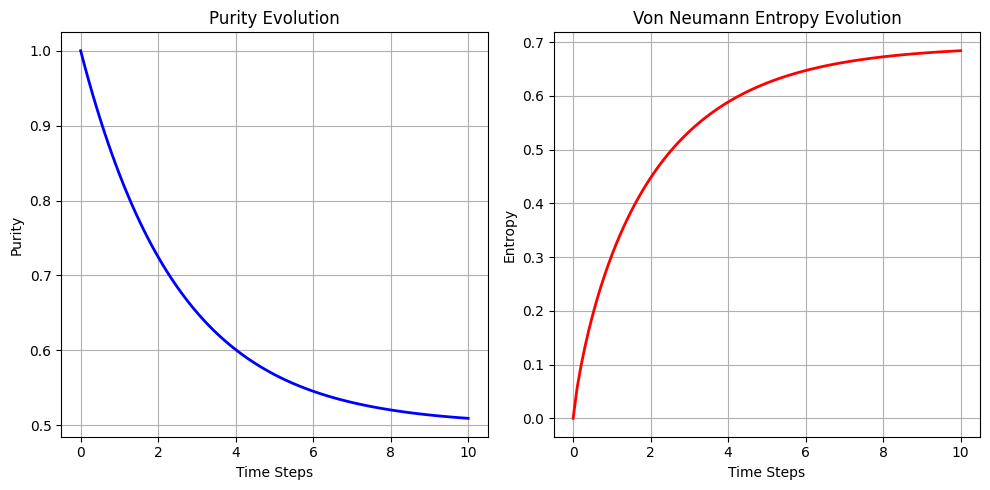

In [9]:
#Track purity and entropy variance across time steps
purities = []
entropies = []

for state in result.states:
    #calculate standard purity: Tr(rho^2)
    purity = (state * state).tr()
    purities.append(purity)

    #caculate von Neumann entropy: S = -Tr(rho log rho)
    entropy = qt.entropy_vn(state)
    entropies.append(entropy)

#Plot the results to verify monotonicity
plt.figure(figsize= (10,5))

#Plot purity
plt.subplot(1,2,1)
plt.plot(t_steps, purities, color='blue',linewidth =2)
plt.title('Purity Evolution')
plt.xlabel('Time Steps')
plt.ylabel('Purity')
plt.grid(True)

#Plot entropy
plt.subplot(1,2,2)
plt.plot(t_steps, entropies, color='red',linewidth =2)
plt.title('Von Neumann Entropy Evolution')
plt.xlabel('Time Steps')
plt.ylabel('Entropy')
plt.grid(True)

plt.tight_layout()
plt.show()